# Phase 2 — Pipeline de treino + experimentos da GNN temporal

Projeto **BraSNAM 2026** — GNN temporal heterogênea para difusão de popularidade musical.

Enquanto o `phase2_apresentacao.ipynb` mostra **como o grafo é construído**, este notebook é o
**ciclo de experimentação de treino**: roda 1 config rápido com curvas ao vivo, opcionalmente
varre uma grid, avalia no **val** (forecasting + retroactive) **e no test held-out** (semana ≥ 208),
e visualiza os resultados — tudo **reusando** as funções já validadas em
`src/music_diffusion_gnn/` (nenhum `.py` é alterado).

**Roteiro:**

0. *(opcional)* Instalar dependências
1. Setup / bootstrap
2. Carregar grafo + timeseries
3. Montar samples (janela causal) com `first_seen` **global**
4. Config interativa (run único) — com modo `SMOKE`
5. Treinar — **Viz 1: curvas treino/val**
6. Avaliar (val forecasting + retroactive **e** test held-out)
7. **Viz 3: predito vs. real + resíduos**
8. **Viz 4: trajetórias temporais**
9. *(Opcional)* Grid — **Viz 2: comparação da grid**
10. Salvar artefatos em `results/phase2_experimentos/`

> Os artefatos de saída vão para `results/phase2_experimentos/` — um diretório **dedicado**,
> para **não** sobrescrever o que o `scripts/run_phase2.py` grava em `results/phase2/`.

## 0. Ambiente — Colab (GPU) ou local

**Colab:** detecta automaticamente e **clona o repositório** (`git clone`) para trazer o código
(`src/`) **e os dados versionados** (`hetero_full.pt`, `node_id_map.json`, `timeseries.parquet`);
instala só o `torch-geometric` (torch + CUDA já vêm no Colab). Ative a GPU em
*Ambiente de execução → Alterar tipo de runtime → GPU (T4)*. Repo privado: defina `GITHUB_TOKEN`
(um PAT) na célula abaixo.

**Local:** ligue `INSTALL_DEPS = True` uma vez (`pip install -e .`) ou use um venv.

> ⚠️ **Pré-requisito:** os 3 artefatos de dados **e** as mudanças de *device* em
> `src/.../trainer.py` precisam estar **commitados e no GitHub** antes de clonar. O `.gitignore`
> já libera esses 3 arquivos; comite-os da máquina que tem os dados. Se `timeseries.parquet`
> passar de 100 MB, o GitHub rejeita o push — nesse caso use **Git LFS** (veja a nota final).

In [1]:
import sys, os, subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# >>> ajuste conforme seu repositório <<<
REPO_URL     = "https://github.com/cristianomendieta/music-influence-gnn.git"
REPO_BRANCH  = "main"
REPO_DIR     = "/content/music-influence-gnn"
GITHUB_TOKEN = ""   # repo privado: cole um PAT aqui OU defina a env GITHUB_TOKEN (vazio = público)

INSTALL_DEPS   = False   # LOCAL: ligue 1x p/ instalar o projeto (pip install -e .)
EXTRA_PIP_ARGS = []      # LOCAL: ["--break-system-packages"] se 'externally-managed'

DATA_FILES = [
    "data/processed/graph/hetero_full.pt",
    "data/processed/graph/node_id_map.json",
    "data/processed/timeseries.parquet",
]

def _clone(url):
    return subprocess.run(["git", "clone", "--depth", "1", "-b", REPO_BRANCH, url, REPO_DIR])

if IS_COLAB:
    # Colab já traz torch+CUDA; clonamos o repo (código + dados) e instalamos só o PyG.
    if not Path(REPO_DIR, "pyproject.toml").exists():
        tok = GITHUB_TOKEN or os.environ.get("GITHUB_TOKEN", "")
        url = REPO_URL.replace("https://", f"https://{tok}@") if tok else REPO_URL
        print(f"Clonando {REPO_URL} (branch {REPO_BRANCH})...")
        if _clone(url).returncode != 0:
            from getpass import getpass
            tok = getpass("Clone falhou (repo privado?). Cole um GitHub token (PAT): ")
            _clone(REPO_URL.replace("https://", f"https://{tok}@")).check_returncode()
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric", "pyarrow"], check=True)
    missing = [f for f in DATA_FILES if not Path(REPO_DIR, f).exists()]
    print("✓ Colab pronto. cwd =", os.getcwd())
    if missing:
        print("⚠️ FALTAM dados no repo clonado:", missing)
        print("   → comite/push esses arquivos (o .gitignore já os libera) ou use Git LFS.")
    else:
        print("✓ dados versionados presentes.")
elif INSTALL_DEPS:
    _anchor = Path(globals().get("__vsc_ipynb_file__", os.getcwd()))
    _root = _anchor if _anchor.is_dir() else _anchor.parent
    while not (_root / "pyproject.toml").exists() and _root != _root.parent:
        _root = _root.parent
    assert (_root / "pyproject.toml").exists(), f"raiz não encontrada a partir de {_anchor}"
    cmd = [sys.executable, "-m", "pip", "install", "-e", str(_root), *EXTRA_PIP_ARGS]
    print("→", " ".join(cmd))
    r = subprocess.run(cmd)
    print("✓ instalado — reinicie o kernel se torch/PyG foram instalados agora." if r.returncode == 0
          else "✘ pip falhou: se 'externally-managed', use venv ou EXTRA_PIP_ARGS=['--break-system-packages'].")
else:
    print("Local, INSTALL_DEPS=False — nada a instalar (mude para True na 1ª vez).")

Clonando https://github.com/cristianomendieta/music-influence-gnn.git (branch main)...
✓ Colab pronto. cwd = /content/music-influence-gnn
✓ dados versionados presentes.


## 1. Setup / bootstrap

Mesma convenção de `ROOT` do notebook de apresentação: sobe a árvore até achar `hetero_full.pt`,
adiciona `src/` ao path e importa **apenas funções já existentes**.

In [2]:
import json, os, sys
from pathlib import Path

# ROOT robusto: ancora no caminho do notebook (VS Code expõe __vsc_ipynb_file__),
# senão no cwd; sobe até achar o pyproject.toml do projeto.
# No Colab via extensão do VS Code, __vsc_ipynb_file__ aponta para o caminho LOCAL
# (WSL), que NÃO existe no runtime remoto — nesse caso caímos no cwd (a célula 0 já
# fez os.chdir(REPO_DIR) no Colab).
_anchor = Path(globals().get("__vsc_ipynb_file__", os.getcwd()))
if not _anchor.exists():
    _anchor = Path(os.getcwd())
ROOT = _anchor if _anchor.is_dir() else _anchor.parent
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), f"raiz do projeto não encontrada a partir de {_anchor}"
sys.path.insert(0, str(ROOT / "src"))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

# Reprodutibilidade global (o train_one também controla via Config.seed)
torch.manual_seed(42)
np.random.seed(42)

# --- funções reusadas (sem reimplementar) ---
from music_diffusion_gnn.training.dataset import (
    aggregate_weekly, temporal_split, build_samples, Sample,
    TRAIN_END_WEEK, TEST_START_WEEK,
)
from music_diffusion_gnn.training.trainer import (
    Config, train_one, run_grid, evaluate, DEFAULT_GRID,
)
from music_diffusion_gnn.models.diffusion_gnn import MusicDiffusionGNN
from music_diffusion_gnn.models.baselines import persistence_predict

GRAPH_DIR = ROOT / "data" / "processed" / "graph"
NMAP_PATH = GRAPH_DIR / "node_id_map.json"

# diretório DEDICADO — não toca em results/phase2/ (do run_phase2.py)
RESULTS = ROOT / "results" / "phase2_experimentos"
RESULTS.mkdir(parents=True, exist_ok=True)

# mapa idx -> spotify_id (para rótulos legíveis nas trajetórias)
node_id_map = json.loads(NMAP_PATH.read_text())
idx_to_song = {int(i): s for s, i in node_id_map["music"]["spotify_id_to_idx"].items()}

# paleta consistente
COL = {"viral50": "#c994c7", "top200": "#dd8855", "music": "#e8743b",
       "gnn": "#1f9ee0", "persist": "#888888", "real": "#222222"}

print("ROOT      :", ROOT)
print("fronteiras:", f"train≤{TRAIN_END_WEEK}  val {TRAIN_END_WEEK+1}-{TEST_START_WEEK-1}  test≥{TEST_START_WEEK}")
print("resultados:", RESULTS)

ROOT      : /content/music-influence-gnn
fronteiras: train≤182  val 183-207  test≥208
resultados: /content/music-influence-gnn/results/phase2_experimentos


## 2. Carregar dados

`hetero_full.pt` (grafo), `timeseries.parquet` (sinal diário) → `aggregate_weekly` (alvo semanal)
→ `temporal_split` (train/val/test por semana, sem vazamento).

In [3]:
g = torch.load(GRAPH_DIR / "hetero_full.pt", weights_only=False)
ts = pd.read_parquet(ROOT / "data" / "processed" / "timeseries.parquet")
weekly = aggregate_weekly(ts)
splits_df = temporal_split(weekly)

n_edges = sum(g[et].edge_index.shape[1] for et in g.edge_types)
print(f"Grafo: {g.num_nodes} nós, {n_edges:,} arestas")
for name in ("train", "val", "test"):
    d = splits_df[name]
    print(f"  {name:5s}: {len(d):>7,} linhas | semanas {d['week'].min()}-{d['week'].max()} | {d['song_id'].nunique()} músicas")

Grafo: 8757 nós, 690,405 arestas
  train: 324,710 linhas | semanas 0-182 | 1525 músicas
  val  :  79,620 linhas | semanas 183-207 | 1667 músicas
  test : 193,342 linhas | semanas 208-260 | 1956 músicas


### 2.5 Dispositivo (GPU / CPU)

Move o grafo para a GPU **uma vez** (transferência única). `train_one`/`evaluate` recebem
`device=DEVICE` e cuidam de mover o modelo e os tensores. Sem GPU, cai para CPU automaticamente.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
g = g.to(DEVICE)   # transferência única do grafo
if DEVICE == "cuda":
    _p = torch.cuda.get_device_properties(0)
    print(f"GPU: {_p.name} | {_p.total_memory / 1e9:.1f} GB")
else:
    print("Sem GPU — CPU. No Colab: Ambiente de execução → Alterar tipo de runtime → GPU (T4).")
print("DEVICE =", DEVICE)

Sem GPU — CPU. No Colab: Ambiente de execução → Alterar tipo de runtime → GPU (T4).
DEVICE = cpu


## 3. Montar samples (janela causal) — `first_seen` **global**

Para prever a semana-alvo `w`, cada `Sample` carrega a janela `[w-W … w-1]` de embeddings
(com *padding* antes de a música estrear). O `build_samples` deriva o `first_seen` do DataFrame
que recebe — então, se passássemos só o split do test, **toda** janela do test (semanas ≥ 208)
ficaria com `first_seen` ≥ 208 e seria **inteiramente mascarada** → test inavaliável.

**Detalhe crítico:** computamos `first_seen` a partir do `weekly` **inteiro** (`fs_global`) e o
passamos a todas as chamadas de `build_samples(..., first_seen=fs_global)`. Isso também corrige o
val (o `run_phase2` usa `first_seen` por-split, que super-mascara músicas que estrearam no train);
o global é mais correto e pode mudar levemente os números de val vs. o script.

In [5]:
# first_seen GLOBAL: {(song_id, chart): primeira_semana}
fs_global = weekly.groupby(["song_id", "chart"])["week"].min().to_dict()

def make_samples(W, song_filter=None):
    # Constrói (train, val, test) Samples com janela W e first_seen global.
    # song_filter: conjunto opcional de song_ids p/ restringir (modo SMOKE).
    out = []
    for name in ("train", "val", "test"):
        df = splits_df[name]
        if song_filter is not None:
            df = df[df["song_id"].isin(song_filter)]
        out.append(build_samples(df, W=W, node_id_map_path=NMAP_PATH, first_seen=fs_global))
    return out  # [train, val, test]

# Exemplo de janela causal (test é o menor split — barato de montar)
_demo = build_samples(splits_df["test"], W=4, node_id_map_path=NMAP_PATH, first_seen=fs_global)
s = _demo[0]
print(f"test (W=4): {len(_demo)} samples")
print("\nSample de exemplo:")
print(f"  song_idx={s.song_idx}  chart={s.chart}  target_week={s.target_week}  y={s.y:.4f}")
print(f"  window_weeks={s.window_weeks}")
print(f"  pad_mask    ={s.pad_mask}")

test (W=4): 192764 samples

Sample de exemplo:
  song_idx=1  chart=1  target_week=208  y=0.0010
  window_weeks=[204, 205, 206, 207]
  pad_mask    =[False, False, False, False]


## 4. Config interativa (run único)

`Config` leve por default (`W=4, hidden=64, layers=2, lr=1e-3`). **`SMOKE=True`** restringe a
~40 músicas presentes nos 3 splits (val/test não-vazios) e poucas épocas — completa em
segundos/poucos minutos. Custo no dataset completo: **~38 s/época em CPU**.

In [6]:
SMOKE = False   # 1ª execução: rápido. Mude para False p/ números reais (~minutos).

cfg = Config(
    W=4, hidden=64, layers=2, lr=1e-3,
    max_epochs=5 if SMOKE else 100,
    patience=3 if SMOKE else 10,
    seed=42,
)

if SMOKE:
    # músicas presentes nos 3 splits → garante val e test não-vazios
    common = (set(splits_df["train"]["song_id"]) &
              set(splits_df["val"]["song_id"]) &
              set(splits_df["test"]["song_id"]))
    smoke_songs = set(sorted(common)[:40])
    print(f"SMOKE: {len(smoke_songs)} músicas")
else:
    smoke_songs = None

tr, va, te = make_samples(cfg.W, song_filter=smoke_songs)
print(f"Samples W={cfg.W}: train={len(tr)}  val={len(va)}  test={len(te)}")
print(f"Config: {cfg}")

Samples W=4: train=321660  val=79336  test=192764
Config: W4_h64_l2_lr1e-03


## 5. Treinar run único — **Viz 1: curvas treino/val**

`train_one` faz early stopping no val MSE e devolve as curvas `train_curve`/`val_curve`
(o `run_phase2.py` nem usa essas curvas).

val_mse=0.006073  params=82,625  tempo=129.5s  épocas=13


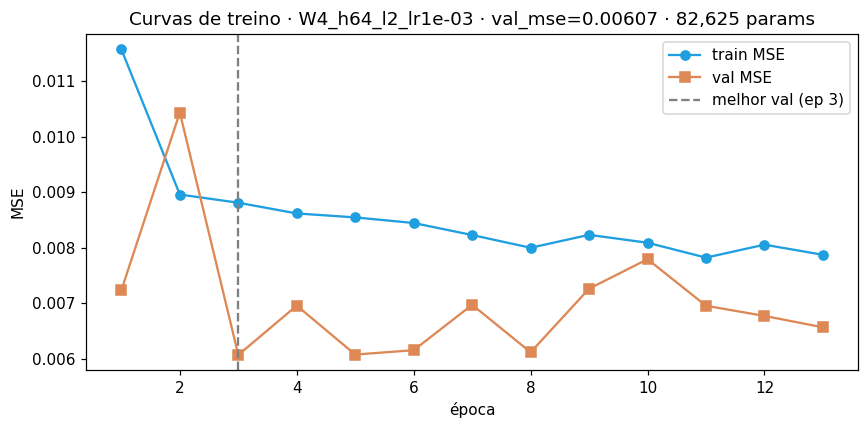

In [7]:
res = train_one(cfg, {"train": tr, "val": va}, g, device=DEVICE)
print(f"val_mse={res.val_mse:.6f}  params={res.n_params:,}  tempo={res.elapsed_sec:.1f}s  épocas={len(res.train_curve)}")

# Viz 1 — curvas treino/val
best_ep = int(np.argmin(res.val_curve))
fig, ax = plt.subplots(figsize=(8, 4))
ep = range(1, len(res.train_curve) + 1)
ax.plot(ep, res.train_curve, "o-", color=COL["gnn"], label="train MSE")
ax.plot(ep, res.val_curve, "s-", color=COL["top200"], label="val MSE")
ax.axvline(best_ep + 1, color="gray", ls="--", label=f"melhor val (ep {best_ep + 1})")
ax.set_xlabel("época"); ax.set_ylabel("MSE")
ax.set_title(f"Curvas de treino · {cfg} · val_mse={res.val_mse:.5f} · {res.n_params:,} params")
ax.legend(); plt.tight_layout()
fig.savefig(RESULTS / "viz1_curvas_treino.png", dpi=120)
plt.show()

## 6. Avaliar o run único — val + **test held-out**

Reconstruímos o modelo, carregamos os melhores pesos e avaliamos com `evaluate`:

- **Val · forecasting** (held-out) e **val · retroactive** (in-sample train+val, teacher-forced).
- **Test held-out** *(sem mudar a fonte)*: chamamos `evaluate` com `splits={"train":tr,"val":te}`
  e `val_split_df=splits_df["test"]`, `mode="forecasting"` — assim a função usa os samples do
  test como se fossem o "val" e calcula a persistência sobre o test. Depois renomeamos
  `predictions_df["mode"]="test"`.

A avaliação usa o **grafo cheio** (`max_cotraj_edges=None`, igual ao `run_phase2`); se houver OOM,
troque `EVAL_COTRAJ` por `cfg.max_cotraj_edges`.

In [ ]:
EVAL_COTRAJ = None  # grafo cheio (como run_phase2); se OOM → use cfg.max_cotraj_edges

model = MusicDiffusionGNN(g.metadata(), n_genre=g["genre"].num_nodes, hidden=cfg.hidden, layers=cfg.layers, dropout=cfg.dropout)
model.load_state_dict(res.best_state_dict)
model.to(DEVICE)
model.eval()

# VAL — forecasting (held-out) e retroactive (in-sample train+val)
fc_val = evaluate(model=model, splits={"train": tr, "val": va}, weekly_df=weekly,
                  val_split_df=splits_df["val"], g=g, mode="forecasting",
                  max_cotraj_edges=EVAL_COTRAJ, device=DEVICE)
retro_val = evaluate(model=model, splits={"train": tr, "val": va}, weekly_df=weekly,
                     val_split_df=splits_df["val"], g=g, mode="retroactive",
                     max_cotraj_edges=EVAL_COTRAJ, device=DEVICE)

# TEST held-out — truque: test entra como "val"; persistência sobre splits_df["test"]
fc_test = evaluate(model=model, splits={"train": tr, "val": te}, weekly_df=weekly,
                   val_split_df=splits_df["test"], g=g, mode="forecasting",
                   max_cotraj_edges=EVAL_COTRAJ, device=DEVICE)
fc_test["predictions_df"]["mode"] = "test"

def _row(tag, r):
    return {
        "conjunto": tag,
        "GNN_MSE_v50": r["mse_viral50"], "persist_v50": r["persist_mse_viral50"],
        "GNN_MSE_t200": r["mse_top200"], "persist_t200": r["persist_mse_top200"],
        "RMSE_v50": r["rmse_viral50"], "RMSE_t200": r["rmse_top200"],
    }

tabela = pd.DataFrame([_row("val (forecasting)", fc_val), _row("test (forecasting)", fc_test)])
print("Retroactive (val, in-sample): "
      f"viral50 MSE={retro_val['mse_viral50']:.6f}  top200 MSE={retro_val['mse_top200']:.6f}")
display(tabela.round(6))

## 7. Viz 3 — predito vs. real + resíduos

A partir dos `predictions_df` (val forecasting + test): scatter `ŷ × y` com a reta `y=ŷ`,
colorido por regime; histogramas de resíduo `(ŷ − y)` separados por viral50/top200, com o MSE
anotado. (O próprio `evaluate` já garante `ŷ ∈ [0, 0.5]` via `assert`.)

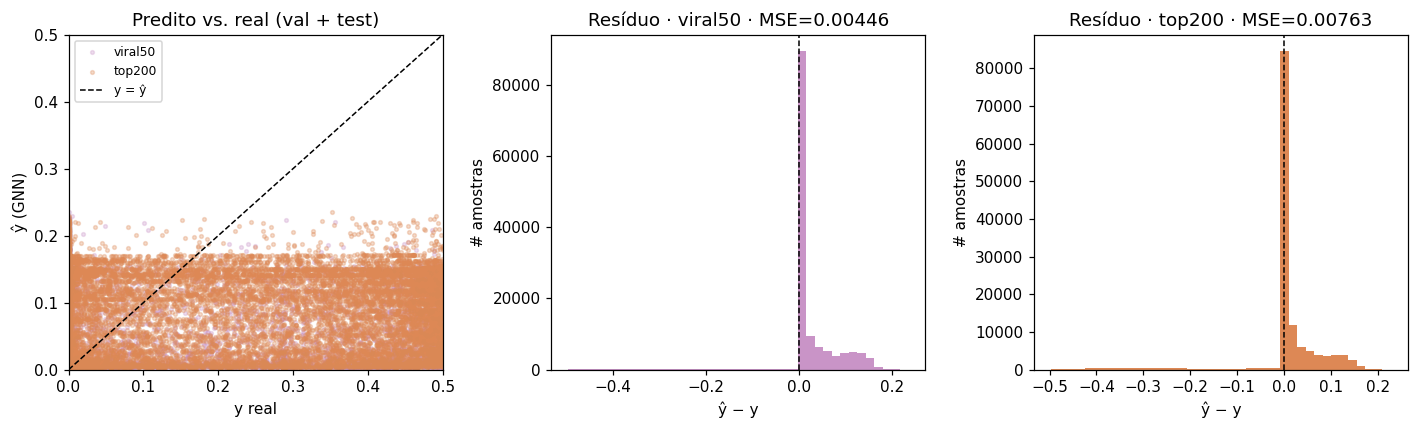

In [9]:
viz_df = pd.concat([fc_val["predictions_df"], fc_test["predictions_df"]], ignore_index=True)
viz_df["regime"] = viz_df["chart_code"].map({0: "viral50", 1: "top200"})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# scatter ŷ × y
ax = axes[0]
for reg in ("viral50", "top200"):
    sub = viz_df[viz_df["regime"] == reg]
    ax.scatter(sub["y_true"], sub["y_pred"], s=6, alpha=0.3, color=COL[reg], label=reg)
ax.plot([0, 0.5], [0, 0.5], "k--", lw=1, label="y = ŷ")
ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
ax.set_xlabel("y real"); ax.set_ylabel("ŷ (GNN)")
ax.set_title("Predito vs. real (val + test)"); ax.legend(fontsize=8)

# resíduos por regime
for ax, reg in ((axes[1], "viral50"), (axes[2], "top200")):
    sub = viz_df[viz_df["regime"] == reg]
    resid = sub["y_pred"] - sub["y_true"]
    ax.hist(resid, bins=40, color=COL[reg], ec="black")
    ax.axvline(0, color="k", ls="--", lw=1)
    mse = float((resid ** 2).mean()) if len(resid) else float("nan")
    ax.set_title(f"Resíduo · {reg} · MSE={mse:.5f}")
    ax.set_xlabel("ŷ − y"); ax.set_ylabel("# amostras")

plt.tight_layout()
fig.savefig(RESULTS / "viz3_predito_vs_real.png", dpi=120)
plt.show()

## 8. Viz 4 — trajetórias temporais

Escolhemos as ~4 séries (`song_idx`, `chart`) com mais semanas previstas e plotamos ao longo do
tempo: **real** (`y_true`), **GNN** (`y_pred`, combinando retroactive train+val e test) e
**persistência** `y(w-1)` (do `weekly`). As regiões treino/val/teste são sombreadas
(fronteiras 182 / 208).

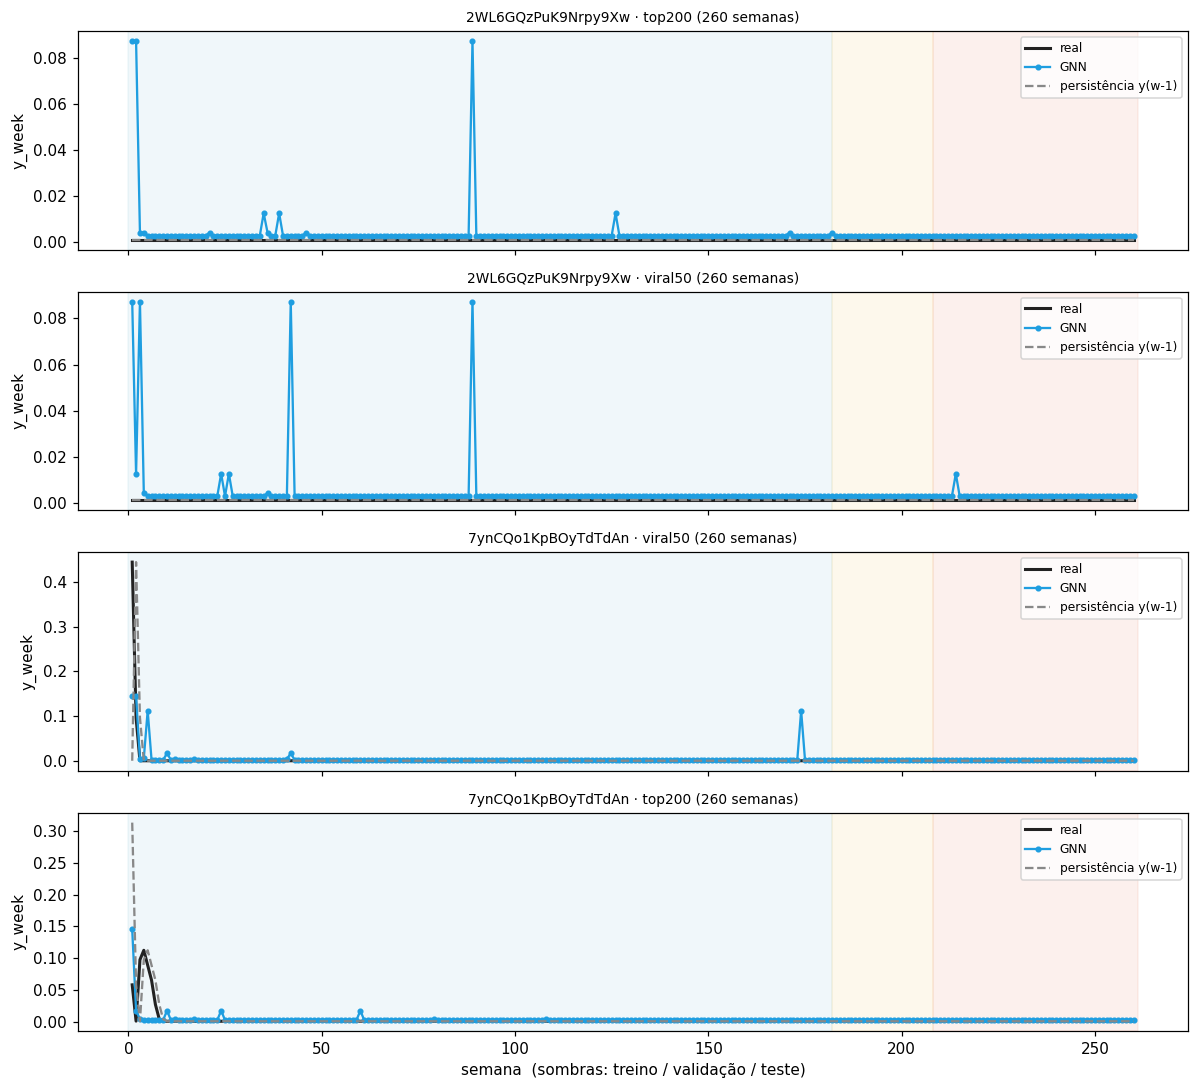

In [10]:
traj = pd.concat([retro_val["predictions_df"], fc_test["predictions_df"]], ignore_index=True)
counts = traj.groupby(["song_idx", "chart_code"]).size().sort_values(ascending=False)
top_keys = list(counts.index[:4])

weekly_idx = weekly.set_index(["song_id", "chart", "week"])["y_week"]
chart_name = {0: "viral50", 1: "top200"}
wmax = int(traj["week"].max())

fig, axes = plt.subplots(len(top_keys), 1, figsize=(11, 2.5 * len(top_keys)), sharex=True)
if len(top_keys) == 1:
    axes = [axes]

for ax, (sidx, ccode) in zip(axes, top_keys):
    sub = traj[(traj["song_idx"] == sidx) & (traj["chart_code"] == ccode)].sort_values("week")
    sid = idx_to_song.get(int(sidx), str(sidx))
    cname = chart_name[int(ccode)]
    persist = [float(weekly_idx.get((sid, cname, int(w) - 1), np.nan)) for w in sub["week"]]
    ax.plot(sub["week"], sub["y_true"], "-", color=COL["real"], lw=2, label="real")
    ax.plot(sub["week"], sub["y_pred"], "o-", color=COL["gnn"], ms=3, label="GNN")
    ax.plot(sub["week"], persist, "--", color=COL["persist"], label="persistência y(w-1)")
    ax.axvspan(0, TRAIN_END_WEEK, color="#86c5da", alpha=0.12)
    ax.axvspan(TRAIN_END_WEEK, TEST_START_WEEK, color="#f3c969", alpha=0.12)
    ax.axvspan(TEST_START_WEEK, wmax + 1, color="#e8896b", alpha=0.12)
    ax.set_ylabel("y_week")
    ax.set_title(f"{sid[:18]} · {cname} ({len(sub)} semanas)", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("semana  (sombras: treino / validação / teste)")
plt.tight_layout()
fig.savefig(RESULTS / "viz4_trajetorias.png", dpi=120)
plt.show()

## 9. *(Opcional)* Grid — seção longa

> ⚠️ **No dataset completo isto leva horas em CPU.** Por isso `RUN_GRID=False` por default; com
> `SMOKE=True` e o subset abaixo (2–3 configs), roda rápido apenas para validar a seção.

Como cada `Config` tem seu próprio `W`, construímos os samples por `W` e chamamos `train_one`
por config (estilo do laço de `run_phase2.py`). Quando todos os configs compartilham o mesmo `W`,
dá para usar `run_grid({"train":..,"val":..}, g)` diretamente.

In [ ]:
RUN_GRID = True  # varredura completa (DEFAULT_GRID = 24 configs) no dataset cheio

# Resiliente a desconexão do Colab:
#  - grava grid_results.parquet APÓS cada config (checkpoint incremental)
#  - salva o melhor state_dict em disco (grid_best_model.pt) sempre que melhora
#  - RETOMA: se o parquet já existe, pula as configs já feitas
# ⚠️ Para forçar um recomeço limpo, apague RESULTS/grid_results.parquet e
#    RESULTS/grid_best_model.pt antes de rodar (ex.: de um teste SMOKE anterior).
grid_df = None
best = None
if RUN_GRID:
    import dataclasses
    GRID_PARQUET = RESULTS / "grid_results.parquet"
    GRID_BEST    = RESULTS / "grid_best_model.pt"

    # DEFAULT_GRID: W∈{4,8,12} × hidden∈{64,128} × layers∈{2,3} × lr∈{1e-3,5e-4} = 24 configs
    grid = list(DEFAULT_GRID)
    grid = [dataclasses.replace(c, seed=42,
                                max_epochs=5 if SMOKE else c.max_epochs,
                                patience=3 if SMOKE else c.patience) for c in grid]

    # samples por W (cada Config tem seu W)
    samples_by_W = {}
    for W in sorted({c.W for c in grid}):
        t_, v_, _ = make_samples(W, song_filter=smoke_songs)
        samples_by_W[W] = {"train": t_, "val": v_}

    # retomada: carrega configs já gravadas e pula-as
    rows, done = [], set()
    if GRID_PARQUET.exists():
        rows = pd.read_parquet(GRID_PARQUET).to_dict("records")
        done = {r["config_str"] for r in rows}
        print(f"Retomando: {len(done)}/{len(grid)} configs já feitas — serão puladas.")

    best = {"val_mse": float("inf")}
    for r in rows:                      # melhor val_mse entre as já feitas
        if r["val_mse"] < best["val_mse"]:
            best = {"val_mse": r["val_mse"], "config_str": r["config_str"]}

    for i, c in enumerate(grid):
        tag = str(c)
        if tag in done:
            print(f"  [{i+1}/{len(grid)}] {tag} — já feito, pulando.")
            continue
        print(f"  [{i+1}/{len(grid)}] {tag} ...", flush=True)
        r = train_one(c, samples_by_W[c.W], g, device=DEVICE)
        print(f"    val_mse={r.val_mse:.6f}  params={r.n_params}  t={r.elapsed_sec:.1f}s")
        rows.append({"config_str": tag, "W": c.W, "hidden": c.hidden, "layers": c.layers,
                     "lr": c.lr, "val_mse": r.val_mse, "n_params": r.n_params,
                     "elapsed_sec": r.elapsed_sec})

        # checkpoint incremental: grava a tabela após CADA config
        pd.DataFrame(rows).sort_values("val_mse").reset_index(drop=True).to_parquet(GRID_PARQUET, index=False)

        # melhor modelo até agora → state_dict + hiperparâmetros em disco
        if r.val_mse < best["val_mse"]:
            best = {"val_mse": r.val_mse, "cfg": c, "state": r.best_state_dict}
            torch.save({"config_str": tag, "W": c.W, "hidden": c.hidden, "layers": c.layers,
                        "lr": c.lr, "dropout": c.dropout, "val_mse": r.val_mse,
                        "state_dict": {k: v.cpu() for k, v in r.best_state_dict.items()}},
                       GRID_BEST)

    # reconstrói best['cfg']/best['state'] do disco (garante viz2 mesmo após retomada)
    if GRID_BEST.exists():
        ck = torch.load(GRID_BEST, map_location="cpu", weights_only=False)
        best = {"val_mse": ck["val_mse"],
                "cfg": Config(W=ck["W"], hidden=ck["hidden"], layers=ck["layers"],
                              lr=ck["lr"], dropout=ck["dropout"]),
                "state": ck["state_dict"]}

    grid_df = pd.DataFrame(rows).sort_values("val_mse").reset_index(drop=True)
    display(grid_df.round(6))
    print("Melhor:", best["cfg"], "val_mse=", round(best["val_mse"], 6))
else:
    print("RUN_GRID=False — pulando a grid. Ligue para varrer hiperparâmetros.")

  [1/24] W4_h64_l2_lr1e-03 ...
    val_mse=0.006082  params=82625  t=127.7s
  [2/24] W4_h64_l2_lr5e-04 ...
    val_mse=0.005667  params=82625  t=265.2s
  [3/24] W4_h64_l3_lr1e-03 ...
    val_mse=0.005473  params=123905  t=359.5s
  [4/24] W4_h64_l3_lr5e-04 ...
    val_mse=0.005615  params=123905  t=358.8s
  [5/24] W4_h128_l2_lr1e-03 ...
    val_mse=0.005361  params=304513  t=281.2s
  [6/24] W4_h128_l2_lr5e-04 ...
    val_mse=0.005971  params=304513  t=155.9s
  [7/24] W4_h128_l3_lr1e-03 ...
    val_mse=0.005336  params=468993  t=387.5s
  [8/24] W4_h128_l3_lr5e-04 ...
    val_mse=0.005291  params=468993  t=383.1s
  [9/24] W8_h64_l2_lr1e-03 ...
    val_mse=0.005244  params=82625  t=268.8s
  [10/24] W8_h64_l2_lr5e-04 ...
    val_mse=0.005372  params=82625  t=267.7s
  [11/24] W8_h64_l3_lr1e-03 ...
    val_mse=0.004967  params=123905  t=649.1s
  [12/24] W8_h64_l3_lr5e-04 ...
    val_mse=0.005035  params=123905  t=656.9s
  [13/24] W8_h128_l2_lr1e-03 ...
    val_mse=0.005123  params=304513  t=2

**Viz 2 — comparação da grid** (só roda se a grid foi executada): barras ordenadas por
`val_mse` + heatmap `(hidden, layers) × (W, lr)`, com linhas de persistência. Por fim, reavalia
o melhor da grid no val **e** test (reusando a lógica da célula 6).

In [ ]:
if grid_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # barras ordenadas por val_mse
    ax = axes[0]
    ax.bar(range(len(grid_df)), grid_df["val_mse"], color=COL["gnn"], ec="black")
    ax.set_xticks(range(len(grid_df)))
    ax.set_xticklabels(grid_df["config_str"], rotation=45, ha="right", fontsize=7)
    ax.axhline(fc_val["persist_mse_viral50"], color=COL["viral50"], ls="--", label="persist viral50")
    ax.axhline(fc_val["persist_mse_top200"],  color=COL["top200"],  ls="--", label="persist top200")
    ax.set_ylabel("val MSE"); ax.set_title("Grid — val MSE por config"); ax.legend(fontsize=8)

    # heatmap (hidden,layers) × (W,lr)
    ax = axes[1]
    piv = grid_df.pivot_table(index=["hidden", "layers"], columns=["W", "lr"], values="val_mse")
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(piv.shape[1]))
    ax.set_xticklabels([f"W{w}·{lr:.0e}" for w, lr in piv.columns], rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(piv.shape[0]))
    ax.set_yticklabels([f"h{h}·l{l}" for h, l in piv.index], fontsize=7)
    fig.colorbar(im, ax=ax, label="val MSE")
    ax.set_title("Heatmap val MSE")
    plt.tight_layout()
    fig.savefig(RESULTS / "viz2_grid.png", dpi=120)
    plt.show()

    # reavaliar o melhor da grid no val + test
    bm = MusicDiffusionGNN(g.metadata(), n_genre=g["genre"].num_nodes, hidden=best["cfg"].hidden,
                           layers=best["cfg"].layers, dropout=best["cfg"].dropout)
    bm.load_state_dict(best["state"]); bm.to(DEVICE); bm.eval()
    bt, bv, bte = make_samples(best["cfg"].W, song_filter=smoke_songs)
    g_val = evaluate(model=bm, splits={"train": bt, "val": bv}, weekly_df=weekly,
                     val_split_df=splits_df["val"], g=g, mode="forecasting", max_cotraj_edges=EVAL_COTRAJ, device=DEVICE)
    g_test = evaluate(model=bm, splits={"train": bt, "val": bte}, weekly_df=weekly,
                      val_split_df=splits_df["test"], g=g, mode="forecasting", max_cotraj_edges=EVAL_COTRAJ, device=DEVICE)
    print("Melhor da grid:")
    print(f"  VAL  viral50 GNN/persist = {g_val['mse_viral50']:.6f} / {g_val['persist_mse_viral50']:.6f}")
    print(f"  TEST viral50 GNN/persist = {g_test['mse_viral50']:.6f} / {g_test['persist_mse_viral50']:.6f}")
else:
    print("Grid não executada — nada a plotar.")

## 10. Salvar artefatos

Em `results/phase2_experimentos/`: `best_model.pt` (state_dict do run único), `predictions.parquet`
(val-forecasting + val-retroactive + test), `grid_results.parquet` (se a grid rodou), os PNGs das
figuras (salvos pelas próprias células de viz) e um `summary.md` no formato do `run_phase2.py`.

In [ ]:
# predições: val forecasting + val retroactive + test
preds_all = pd.concat(
    [fc_val["predictions_df"], retro_val["predictions_df"], fc_test["predictions_df"]],
    ignore_index=True,
)
preds_all.to_parquet(RESULTS / "predictions.parquet", index=False)

# modelo do run único
torch.save({k: v.cpu() for k, v in res.best_state_dict.items()}, RESULTS / "best_model.pt")

# grid (se rodou)
if grid_df is not None:
    grid_df.to_parquet(RESULTS / "grid_results.parquet", index=False)

def _better(a, b):
    return "✓ melhor" if a < b else "✗ pior"

lines = [
    "# Phase 2 — Experimentos (notebook)\n\n",
    f"**Config (run único):** `{cfg}`\n",
    f"**Params:** {res.n_params:,}  |  **SMOKE:** {SMOKE}\n\n",
    "## Forecasting — VAL (held-out)\n\n",
    "| Regime | GNN MSE | GNN RMSE | Persistência MSE | Δ |\n",
    "|--------|---------|----------|------------------|---|\n",
    f"| viral50 | {fc_val['mse_viral50']:.6f} | {fc_val['rmse_viral50']:.6f} | {fc_val['persist_mse_viral50']:.6f} | {_better(fc_val['mse_viral50'], fc_val['persist_mse_viral50'])} |\n",
    f"| top200  | {fc_val['mse_top200']:.6f} | {fc_val['rmse_top200']:.6f} | {fc_val['persist_mse_top200']:.6f} | {_better(fc_val['mse_top200'], fc_val['persist_mse_top200'])} |\n\n",
    "## Forecasting — TEST (held-out, semana ≥ 208)\n\n",
    "| Regime | GNN MSE | GNN RMSE | Persistência MSE | Δ |\n",
    "|--------|---------|----------|------------------|---|\n",
    f"| viral50 | {fc_test['mse_viral50']:.6f} | {fc_test['rmse_viral50']:.6f} | {fc_test['persist_mse_viral50']:.6f} | {_better(fc_test['mse_viral50'], fc_test['persist_mse_viral50'])} |\n",
    f"| top200  | {fc_test['mse_top200']:.6f} | {fc_test['rmse_top200']:.6f} | {fc_test['persist_mse_top200']:.6f} | {_better(fc_test['mse_top200'], fc_test['persist_mse_top200'])} |\n\n",
    "## Retroactive — VAL (in-sample train+val)\n\n",
    f"- viral50 MSE={retro_val['mse_viral50']:.6f}  RMSE={retro_val['rmse_viral50']:.6f}\n",
    f"- top200  MSE={retro_val['mse_top200']:.6f}  RMSE={retro_val['rmse_top200']:.6f}\n\n",
    "## Artefatos\n\n",
    "- `results/phase2_experimentos/best_model.pt`\n",
    "- `results/phase2_experimentos/predictions.parquet`\n",
]
if grid_df is not None:
    lines.append("- `results/phase2_experimentos/grid_results.parquet`\n")
lines.append("- PNGs: viz1_curvas_treino, viz3_predito_vs_real, viz4_trajetorias"
             + (", viz2_grid" if grid_df is not None else "") + "\n")

(RESULTS / "summary.md").write_text("".join(lines))

print("Artefatos em", RESULTS)
for p in sorted(RESULTS.iterdir()):
    print("  ", p.name)